#Wheat Rust Disease Detection
## DeepLabV3+ with ResNet-50 Backbone — Binary Semantic Segmentation
**Dataset:** abdur548/nwrd-patched (Kaggle) | **Framework:** PyTorch + segmentation-models-pytorch

In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "abdur548"
os.environ['KAGGLE_KEY']      = "a83df7326200f6f046254700891fcf1b"

In [2]:
import kagglehub


path = kagglehub.dataset_download('abdur548/nwrd-patched')
print('Dataset path:', path)

100%|██████████| 1.99G/1.99G [01:58<00:00, 18.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/abdur548/nwrd-patched/versions/1


In [3]:
# Cell 2 — Install dependencies
!pip install segmentation-models-pytorch albumentations wandb torchmetrics monai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 120.6 MB/s eta 0:00:00


In [4]:
# Cell 3 — Imports & seed
import torch, numpy as np, os, random
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import wandb

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('CUDA available:', torch.cuda.is_available())

Device: cuda
CUDA available: True


In [5]:
# Cell 4 — Config
class Config:
    # paths — set after download
    train_img_dir   = ''
    train_mask_dir  = ''
    val_img_dir     = ''
    val_mask_dir    = ''

    # model
    encoder         = 'efficientnet-b4'
    encoder_weights = 'imagenet'
    num_classes     = 1
    dropout         = 0.3

    # training
    epochs          = 15
    batch_size      = 8
    lr              = 5e-5
    img_size        = 512

    # preprocessing
    bg_keep_ratio   = 0.10

    # loss
    dice_weight     = 0.7
    bce_weight      = 0.3

    # misc
    seed            = 42
    checkpoint_path = '/content/best_model.pth'
    results_path    = '/content/results.json'

cfg = Config()
print(f'Encoder: {cfg.encoder} | LR: {cfg.lr} | Epochs: {cfg.epochs} | Batch: {cfg.batch_size}')

Encoder: efficientnet-b4 | LR: 5e-05 | Epochs: 15 | Batch: 8


In [6]:
# Cell 5 — Inspect dataset structure & set paths
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'  {indent}{f}')

1/
  wheat_rust_patches/
    processing_stats.json
    README.md
    train/
      masks/
      images/
    val/
      masks/
      images/
    test/
      masks/
      images/


In [7]:
cfg.train_img_dir  = os.path.join(path, 'wheat_rust_patches', 'train', 'images')
cfg.train_mask_dir = os.path.join(path, 'wheat_rust_patches', 'train', 'masks')
cfg.val_img_dir    = os.path.join(path, 'wheat_rust_patches', 'val', 'images')
cfg.val_mask_dir   = os.path.join(path, 'wheat_rust_patches', 'val', 'masks')

for p in [cfg.train_img_dir, cfg.train_mask_dir, cfg.val_img_dir, cfg.val_mask_dir]:
    print(p, '->', os.path.exists(p))

/root/.cache/kagglehub/datasets/abdur548/nwrd-patched/versions/1/wheat_rust_patches/train/images -> True
/root/.cache/kagglehub/datasets/abdur548/nwrd-patched/versions/1/wheat_rust_patches/train/masks -> True
/root/.cache/kagglehub/datasets/abdur548/nwrd-patched/versions/1/wheat_rust_patches/val/images -> True
/root/.cache/kagglehub/datasets/abdur548/nwrd-patched/versions/1/wheat_rust_patches/val/masks -> True


In [8]:

# Cell 6 — Background filtering & Dataset class
import cv2

def analyze_mask(mask_path):
    mask = np.array(Image.open(mask_path).convert('L'))
    mask = (mask > 127).astype(np.float32)
    return mask.sum() / mask.size

def filter_samples(img_dir, mask_dir, bg_keep_ratio=0.5):
    files = sorted(os.listdir(img_dir))
    disease, background = [], []
    for f in files:
        ratio = analyze_mask(os.path.join(mask_dir, f))
        (disease if ratio > 0 else background).append(f)
    kept_bg = random.sample(background, int(len(background) * bg_keep_ratio))
    print(f'Disease: {len(disease)} | BG kept: {len(kept_bg)}/{len(background)}')
    return disease + kept_bg

class WheatRustDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, mask_dir, files, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.files     = files
        self.transform = transform

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        f    = self.files[idx]
        img  = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, f)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, f), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img, mask.unsqueeze(0)

In [9]:
# Cell 7 — Transforms & DataLoaders
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.Resize(cfg.img_size, cfg.img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.ElasticTransform(p=0.5),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(cfg.img_size, cfg.img_size),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

train_files = filter_samples(cfg.train_img_dir, cfg.train_mask_dir, cfg.bg_keep_ratio)
val_files   = sorted(os.listdir(cfg.val_img_dir))

train_ds = WheatRustDataset(cfg.train_img_dir, cfg.train_mask_dir, train_files, train_tf)
val_ds   = WheatRustDataset(cfg.val_img_dir,   cfg.val_mask_dir,   val_files,   val_tf)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
imgs, masks = next(iter(train_loader))
print(f'Batch shape — images: {imgs.shape} | masks: {masks.shape}')

Disease: 2597 | BG kept: 556/5563
Train batches: 395 | Val batches: 60
Batch shape — images: torch.Size([8, 3, 512, 512]) | masks: torch.Size([8, 1, 512, 512])


In [10]:
# Cell 8 — Loss function
def compute_pos_weight(loader):
    pos, neg = 0, 0
    for _, masks in loader:
        pos += masks.sum().item()
        neg += (1 - masks).sum().item()
    pw = neg / (pos + 1e-8)
    print(f'pos_weight: {pw:.2f}  (neg={neg:.0f}, pos={pos:.0f})')
    return torch.tensor([pw], device=device)

pos_weight = compute_pos_weight(train_loader)

class CombinedLoss(nn.Module):
    def __init__(self, dice_w=0.6, bce_w=0.4, pos_weight=None):
        super().__init__()
        self.dice_w = dice_w
        self.bce_w  = bce_w
        self.dice   = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.bce    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, pred, target):
        return self.dice_w * self.dice(pred, target) + self.bce_w * self.bce(pred, target)

criterion = CombinedLoss(cfg.dice_weight, cfg.bce_weight, pos_weight)

pos_weight: 2.96  (neg=617634606, pos=208905426)


In [11]:
!pip install efficientnet_pytorch -q

  Preparing metadata (setup.py) ... done


In [12]:
# Cell 9 — CANet with EfficientNet-B4 backbone
import torch
import torch.nn as nn
import torch.nn.functional as F
from efficientnet_pytorch import EfficientNet

# ── helpers ──────────────────────────────────────────────────────────────────

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1, d=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


# ── Context Flow (shallow encoder-decoder per scale) ─────────────────────────

class ContextFlow(nn.Module):
    """One information flow in CAM — shallow enc-dec at a given downsample scale."""
    def __init__(self, in_ch, out_ch, scale):
        super().__init__()
        self.scale   = scale
        self.encode  = ConvBNReLU(in_ch, out_ch, k=3, p=1)
        self.decode  = ConvBNReLU(out_ch, out_ch, k=3, p=1)

    def forward(self, x):
        h, w = x.shape[-2:]
        if self.scale > 1:
            x_down = F.avg_pool2d(x, self.scale)
        else:
            x_down = x
        feat = self.encode(x_down)
        feat = self.decode(feat)
        if self.scale > 1:
            feat = F.interpolate(feat, size=(h, w),
                                 mode='bilinear', align_corners=False)
        return feat


# ── Attention-guided re-fusion ────────────────────────────────────────────────

class AttentionFusion(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.att = nn.Sequential(
            nn.Conv2d(in_ch, in_ch // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch // 4, in_ch, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.att(x)


# ── Chained Context Aggregation Module (CAM) ─────────────────────────────────

class CAM(nn.Module):
    """
    Series-parallel hybrid:
      - Global Flow  (serial):   continuously enlarges receptive field
      - Context Flows (parallel): encode region-based context at scales 2,4,8
      - Pre-fusion → attention re-fusion
    """
    def __init__(self, in_ch, out_ch=256):
        super().__init__()
        self.global_flow = nn.Sequential(
            ConvBNReLU(in_ch, out_ch, k=3, p=2, d=2),
            ConvBNReLU(out_ch, out_ch, k=3, p=4, d=4),
            ConvBNReLU(out_ch, out_ch, k=3, p=8, d=8),
        )
        self.context_flows = nn.ModuleList([
            ContextFlow(in_ch, out_ch, scale=2),
            ContextFlow(in_ch, out_ch, scale=4),
            ContextFlow(in_ch, out_ch, scale=8),
        ])
        # pre-fusion: concat global + 3 context flows → compress
        self.pre_fusion = ConvBNReLU(out_ch * 4, out_ch, k=1, p=0)
        # re-fusion: attention-guided
        self.re_fusion  = AttentionFusion(out_ch)
        self.out_conv   = ConvBNReLU(out_ch, out_ch, k=3, p=1)

    def forward(self, x):
        gf  = self.global_flow(x)
        cfs = [cf(x) for cf in self.context_flows]
        # pre-fusion
        fused = self.pre_fusion(torch.cat([gf] + cfs, dim=1))
        # re-fusion with attention
        fused = self.re_fusion(fused)
        return self.out_conv(fused)


# ── Asymmetric Decoder ────────────────────────────────────────────────────────

class AsymmetricDecoder(nn.Module):
    """
    Upsamples CAM output, fuses with low-level EfficientNet features,
    recovers spatial detail asymmetrically (more convs on the way up).
    """
    def __init__(self, high_ch, low_ch, out_ch=128):
        super().__init__()
        self.low_reduce = ConvBNReLU(low_ch, 48, k=1, p=0)
        self.fuse = nn.Sequential(
            ConvBNReLU(high_ch + 48, out_ch, k=3, p=1),
            ConvBNReLU(out_ch, out_ch, k=3, p=1),
        )

    def forward(self, high, low):
        high_up = F.interpolate(high, size=low.shape[-2:],
                                mode='bilinear', align_corners=False)
        low_r   = self.low_reduce(low)
        return self.fuse(torch.cat([high_up, low_r], dim=1))


# ── Full CANet ────────────────────────────────────────────────────────────────

class CANet(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # EfficientNet-B4 encoder
        self.encoder   = EfficientNet.from_pretrained('efficientnet-b4')

        # EfficientNet-B4 feature channels:
        #   _blocks[1]  → 24ch  (1/4 resolution)  — low-level features
        #   _blocks[21] → 160ch (1/16 resolution)  — used for CAM (reduction layer)
        # final _conv_head → 1792ch (1/32)
        self.reduce    = ConvBNReLU(1792, 512, k=1, p=0)
        self.cam       = CAM(in_ch=512, out_ch=256)
        self.decoder = AsymmetricDecoder(high_ch=256, low_ch=32, out_ch=128)
        self.dropout   = nn.Dropout2d(p=dropout)
        self.head      = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, 1)   # raw logits
        )

    def forward(self, x):
        # ── encode ──
        x_enc = self.encoder.extract_features(x)           # (B,1792,H/32,W/32)

        # low-level features from early block
        endpoints = self.encoder.extract_endpoints(x)
        low       = endpoints['reduction_2']               # (B,24,H/4,W/4)

        # ── CAM ──
        x_enc = self.reduce(x_enc)                         # (B,512,H/32,W/32)
        x_cam = self.cam(x_enc)                            # (B,256,H/32,W/32)

        # ── decode ──
        x_dec = self.decoder(x_cam, low)                   # (B,128,H/4,W/4)
        x_dec = self.dropout(x_dec)

        # ── head + upsample to input size ──
        out   = self.head(x_dec)                           # (B,1,H/4,W/4)
        out   = F.interpolate(out, scale_factor=4,
                              mode='bilinear', align_corners=False)
        return out                                         # (B,1,H,W)


# ── Init ─────────────────────────────────────────────────────────────────────
!pip install efficientnet_pytorch -q

model     = CANet(dropout=0.3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=1e-7
)
scaler    = torch.cuda.amp.GradScaler()

cfg.encoder = 'efficientnet-b4-canet'

# shape check
with torch.no_grad():
    x = torch.randn(2, 3, 512, 512).to(device)
    print('Output shape:', model(x).shape)  # expect (2,1,512,512)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth


100%|██████████| 74.4M/74.4M [00:01<00:00, 39.7MB/s]


Loaded pretrained weights for efficientnet-b4


/tmp/ipykernel_2168/1651975316.py:171: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


Output shape: torch.Size([2, 1, 512, 512])


In [ ]:
# Cell 10 — Metrics
def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    tn = ((1 - pred) * (1 - target)).sum().item()
    return {
        'iou':         tp / (tp + fp + fn + 1e-8),
        'dice':        2*tp / (2*tp + fp + fn + 1e-8),
        'precision':   tp / (tp + fp + 1e-8),
        'recall':      tp / (tp + fn + 1e-8),
        'specificity': tn / (tn + fp + 1e-8),
        'accuracy':    (tp + tn) / (tp + tn + fp + fn + 1e-8),
    }

In [14]:
# Cell 11 — Train & validate epoch functions
def train_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    total_loss  = 0
    all_metrics = {k: 0 for k in ['iou','dice','precision','recall','specificity','accuracy']}
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss  = criterion(preds, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        m = compute_metrics(preds.detach(), masks)
        for k in all_metrics: all_metrics[k] += m[k]
    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


def val_epoch(model, loader, criterion, threshold=0.5):
    model.eval()
    total_loss  = 0
    all_metrics = {k: 0 for k in ['iou','dice','precision','recall','specificity','accuracy']}
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Val', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss  = criterion(preds, masks)
            total_loss += loss.item()
            m = compute_metrics(preds, masks, threshold)
            for k in all_metrics: all_metrics[k] += m[k]
    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}

In [15]:
# Cell 12 — W&B init + training loop
import wandb
os.environ['WANDB_API_KEY'] = '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'
wandb.login(key=os.environ['WANDB_API_KEY'], relogin=True)

wandb.init(project='wheat-rust-detection', config={
    'encoder':       cfg.encoder,
    'lr':            cfg.lr,
    'epochs':        cfg.epochs,
    'batch_size':    cfg.batch_size,
    'loss':          f'{cfg.dice_weight}*Dice + {cfg.bce_weight}*BCE',
    'bg_keep_ratio': cfg.bg_keep_ratio
})

history  = {k: [] for k in ['train_loss','val_loss','val_iou','val_dice']}
best_iou = 0.0

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False
print("Encoder frozen for first 3 epochs")

for epoch in range(cfg.epochs):
    if epoch == 3:
        for param in model.encoder.parameters():
            param.requires_grad = True
        print("Encoder unfrozen")

    tr_loss, tr_m = train_epoch(model, train_loader, optimizer, scaler, criterion)
    vl_loss, vl_m = val_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_iou'].append(vl_m['iou'])
    history['val_dice'].append(vl_m['dice'])

    wandb.log({
        'epoch':           epoch + 1,
        'train_loss':      tr_loss,
        'val_loss':        vl_loss,
        'val_iou':         vl_m['iou'],
        'val_dice':        vl_m['dice'],
        'val_precision':   vl_m['precision'],
        'val_recall':      vl_m['recall'],
        'val_specificity': vl_m['specificity'],
        'val_accuracy':    vl_m['accuracy'],
        'lr':              optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1:02d}/{cfg.epochs} | "
          f"TrLoss: {tr_loss:.4f} | VlLoss: {vl_loss:.4f} | "
          f"IoU: {vl_m['iou']:.4f} | Dice: {vl_m['dice']:.4f}")

    if vl_m['iou'] > best_iou:
        best_iou = vl_m['iou']
        torch.save({
            'epoch':     epoch + 1,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'iou':       best_iou
        }, cfg.checkpoint_path)
        print(f'  ✓ Saved best model (IoU: {best_iou:.4f})')

wandb.finish()
print(f'\nDone. Best Val IoU: {best_iou:.4f}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: syedabdurrehman548 (syedabdurrehman548-nust) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Encoder frozen for first 3 epochs


Epoch 01/15 | TrLoss: 0.4669 | VlLoss: 0.2499 | IoU: 0.4869 | Dice: 0.5680
  ✓ Saved best model (IoU: 0.4869)


Epoch 02/15 | TrLoss: 0.3985 | VlLoss: 0.2463 | IoU: 0.5068 | Dice: 0.5833
  ✓ Saved best model (IoU: 0.5068)


Epoch 03/15 | TrLoss: 0.3922 | VlLoss: 0.2126 | IoU: 0.5301 | Dice: 0.5996
  ✓ Saved best model (IoU: 0.5301)
Encoder unfrozen


...

Epoch 13/15 | TrLoss: 0.2220 | VlLoss: 0.1729 | IoU: 0.5668 | Dice: 0.6240


Epoch 14/15 | TrLoss: 0.2150 | VlLoss: 0.1818 | IoU: 0.5582 | Dice: 0.6183


Epoch 15/15 | TrLoss: 0.2075 | VlLoss: 0.1791 | IoU: 0.5597 | Dice: 0.6191


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,▇▆▃▂██▇▇▆▄▃▂▂▁█
train_loss,█▆▆▅▄▄▄▃▃▂▂▂▁▁▁
val_accuracy,▁▂▅▃▇▄▃█▇▆▅▅▄▄▄
val_dice,▁▂▄▄▆▆██▇▇▆▇▆▆▆
val_iou,▁▂▄▅▆▅▇█▇▇▆▇▇▆▆
val_loss,██▅▅▃▃▃▁▂▁▁▁▁▂▂
val_precision,▁▂▅▄▇▄▆█▇▇▆▇▆▆▆
val_recall,▂▃▁▄▂▅█▄▄▅▅▅▅▅▅
val_specificity,▁▂▆▂▇▃▁█▆▅▄▄▃▃▂
epoch,15



Done. Best Val IoU: 0.5817




---



In [16]:
import pandas as pd

ckpt = torch.load(cfg.checkpoint_path)
model.load_state_dict(ckpt['model'])
model.eval()

# Collect val predictions
all_preds, all_masks = [], []
with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc='Collecting preds'):
        preds = torch.sigmoid(model(imgs.to(device))).cpu()
        all_preds.append(preds)
        all_masks.append(masks)
all_preds = torch.cat(all_preds)
all_masks  = torch.cat(all_masks)

# Sweep on F1
rows = []
for t in np.arange(0.25, 0.80, 0.02):
    pb = (all_preds > t).float()
    tp = (pb * all_masks).sum().item()
    fp = (pb * (1 - all_masks)).sum().item()
    fn = ((1 - pb) * all_masks).sum().item()
    tn = ((1 - pb) * (1 - all_masks)).sum().item()
    f1  = 2*tp / (2*tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    rows.append({'threshold': round(t, 2), 'f1': round(f1, 4), 'iou': round(iou, 4)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
best_thresh = df.loc[df['f1'].idxmax(), 'threshold']
print(f"\nBest threshold (by F1): {best_thresh}")

 threshold     f1    iou
      0.25 0.8593 0.7532
      0.27 0.8631 0.7592
      0.29 0.8664 0.7644
      0.31 0.8694 0.7689
      0.33 0.8720 0.7730
      0.35 0.8744 0.7769
      0.37 0.8766 0.7804
      0.39 0.8786 0.7835
      0.41 0.8804 0.7863
      0.43 0.8820 0.7889
      0.45 0.8834 0.7912
      0.47 0.8848 0.7935
      0.49 0.8861 0.7955
      0.51 0.8873 0.7974
      0.53 0.8884 0.7992
      0.55 0.8894 0.8008
      0.57 0.8904 0.8024
      0.59 0.8913 0.8038
      0.61 0.8921 0.8052
      0.63 0.8929 0.8066
      0.65 0.8938 0.8079
      0.67 0.8945 0.8091
      0.69 0.8951 0.8101
      0.71 0.8956 0.8109
      0.73 0.8959 0.8114
      0.75 0.8960 0.8116
      0.77 0.8959 0.8114
      0.79 0.8957 0.8111

Best threshold (by F1): 0.75



=== Final Metrics (threshold=0.75) ===
  IoU           : 0.8116  → FAIL ✗
  F1 / Dice     : 0.8960  → FAIL ✗
  Precision     : 0.9207  → 
  Recall        : 0.8726  → 
  Specificity   : 0.9942  → PASS ✓
  Accuracy      : 0.9855  → PASS ✓


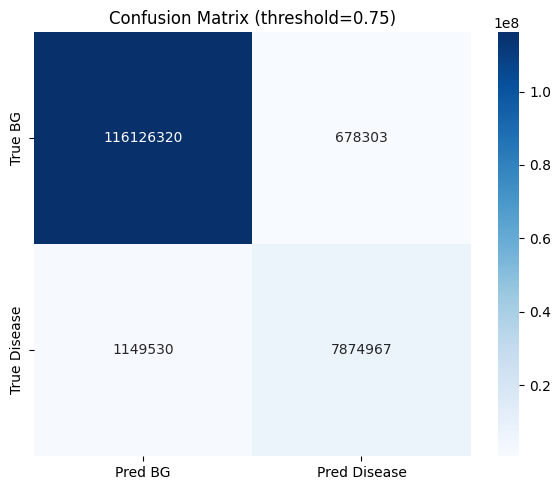

Results saved.


In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Final metrics at best threshold
pb = (all_preds > best_thresh).float()
tp = (pb * all_masks).sum().item()
fp = (pb * (1 - all_masks)).sum().item()
fn = ((1 - pb) * all_masks).sum().item()
tn = ((1 - pb) * (1 - all_masks)).sum().item()

final = {
    'IoU':         round(tp / (tp + fp + fn + 1e-8), 4),
    'F1 / Dice':   round(2*tp / (2*tp + fp + fn + 1e-8), 4),
    'Precision':   round(tp / (tp + fp + 1e-8), 4),
    'Recall':      round(tp / (tp + fn + 1e-8), 4),
    'Specificity': round(tn / (tn + fp + 1e-8), 4),
    'Accuracy':    round((tp + tn) / (tp + tn + fp + fn + 1e-8), 4),
}

targets = {'IoU': 0.83, 'F1 / Dice': 0.90, 'Accuracy': 0.90, 'Specificity': 0.95}
print(f"\n=== Final Metrics (threshold={best_thresh}) ===")
for k, v in final.items():
    target = targets.get(k)
    status = f"→ {'PASS ✓' if target and v >= target else 'FAIL ✗' if target else ''}"
    print(f"  {k:14s}: {v:.4f}  {status}")

# Confusion matrix
cm = confusion_matrix(
    all_masks.numpy().flatten().astype(int),
    pb.numpy().flatten().astype(int)
)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred BG', 'Pred Disease'],
            yticklabels=['True BG', 'True Disease'])
plt.title(f'Confusion Matrix (threshold={best_thresh})')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Save results
import json
results = {
    'best_threshold': float(best_thresh),
    'final_metrics':  final,
    'history':        history
}
with open('/content/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved.")

Disease patches in val set: 124


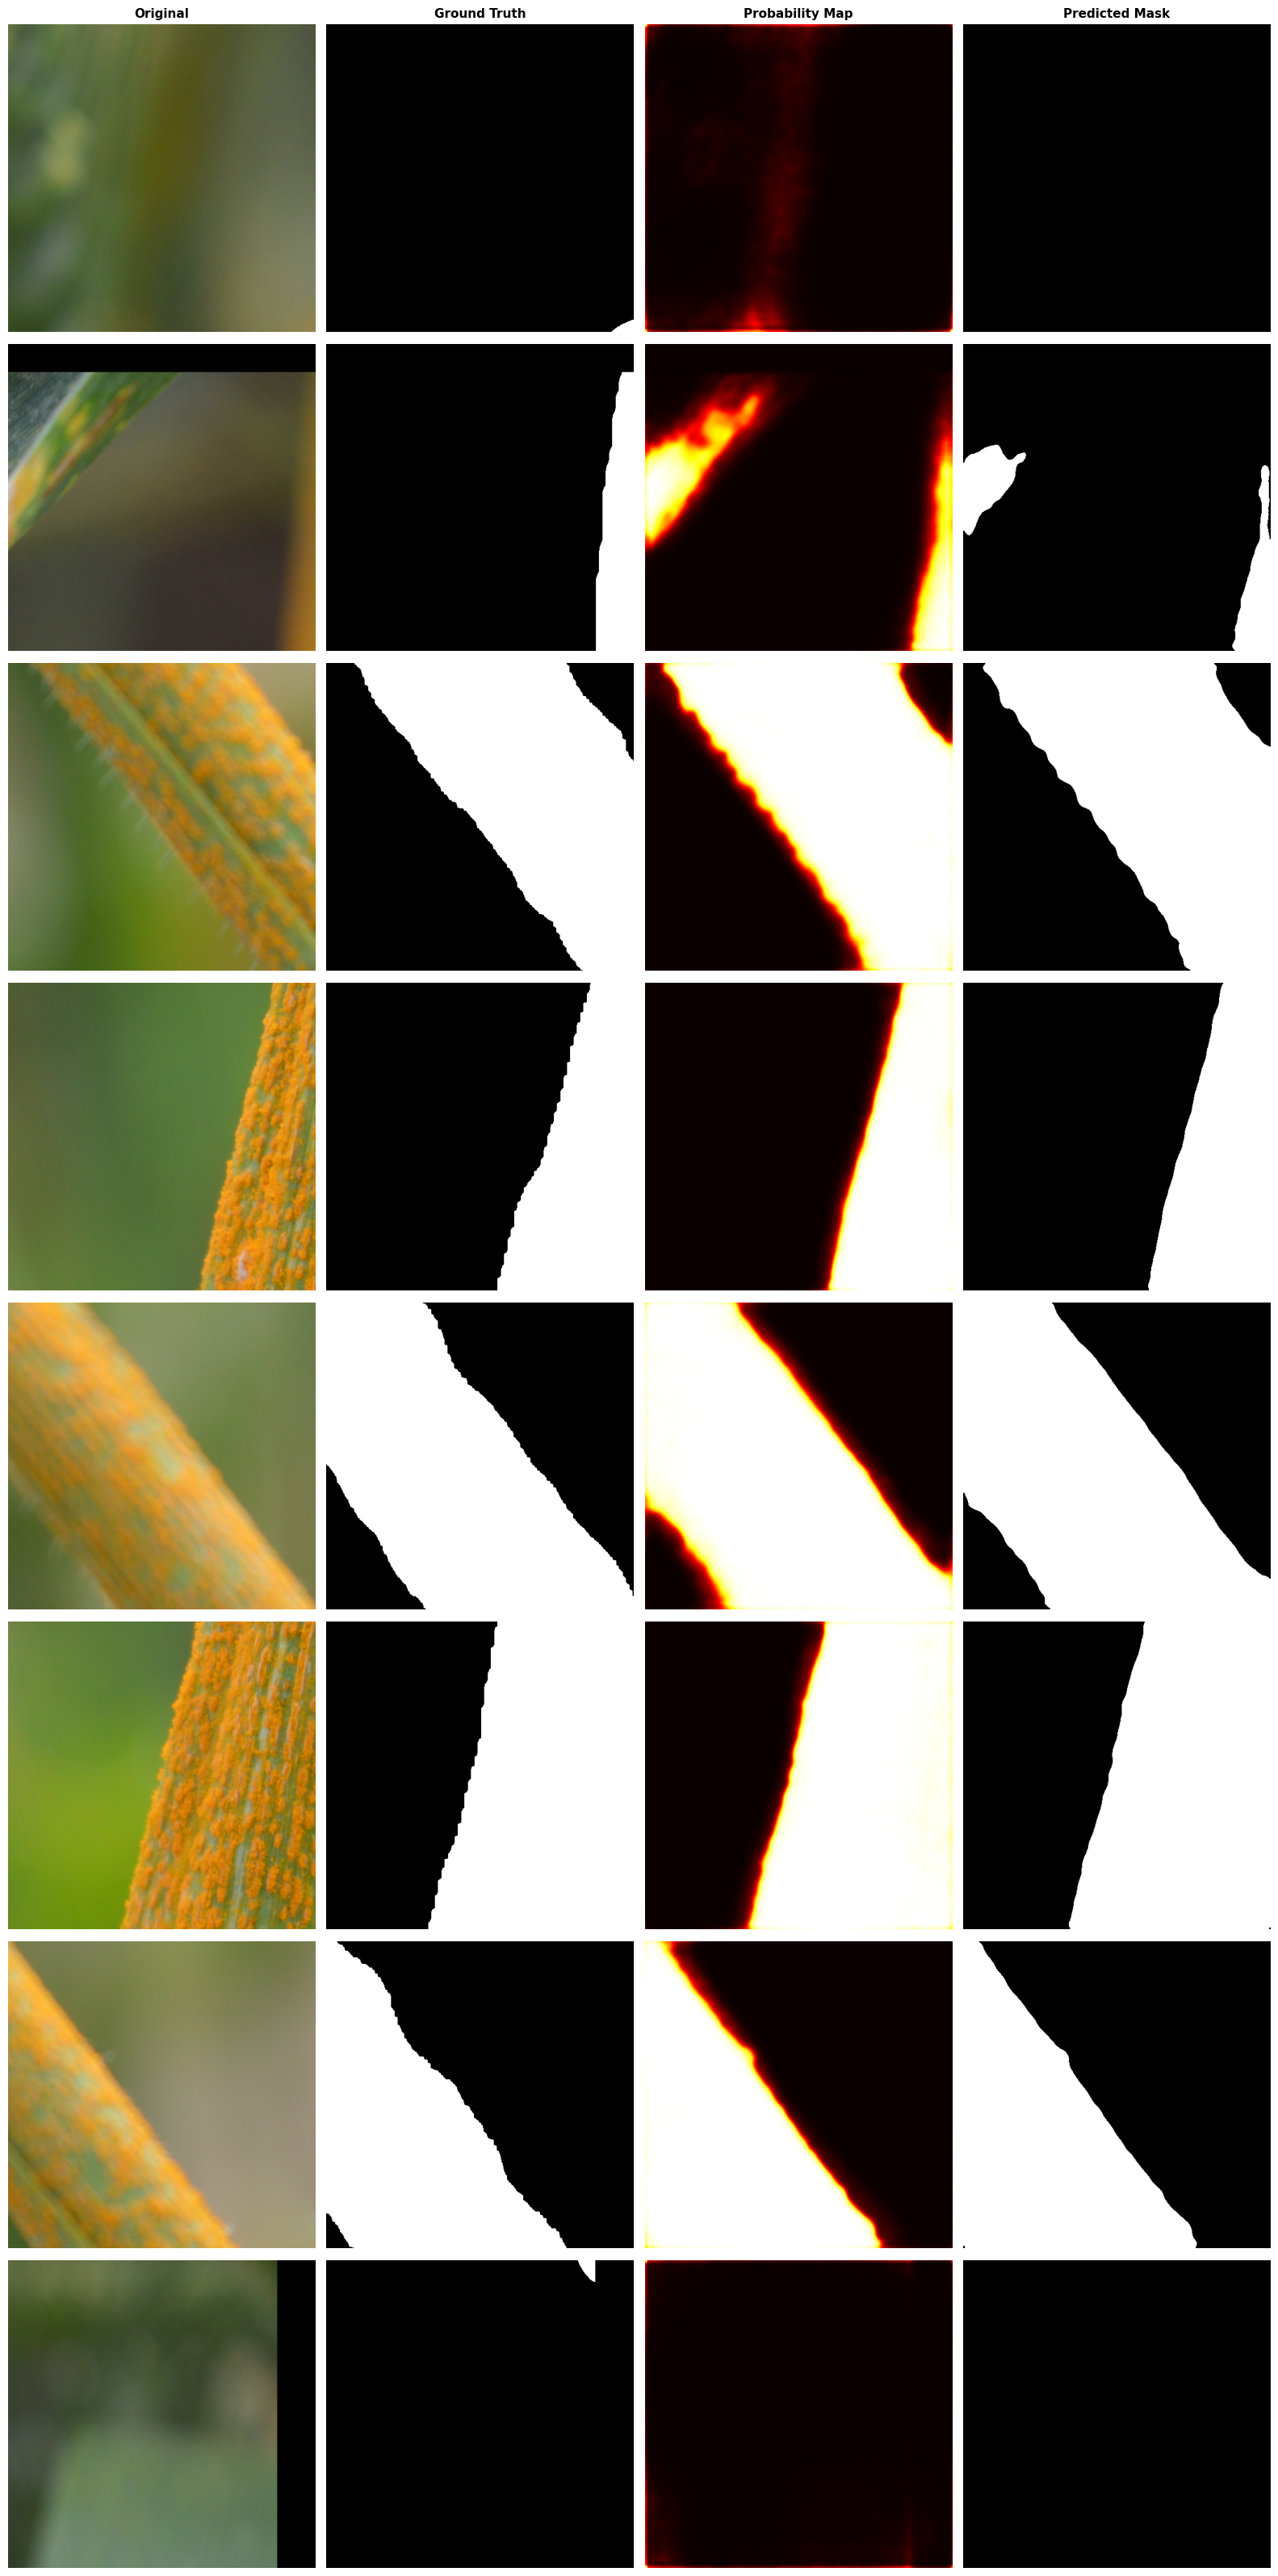

Qualitative results saved.


In [18]:
def denorm(t):
    m, s = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    t = t.clone()
    for i in range(3): t[i] = t[i] * s[i] + m[i]
    return t.clamp(0, 1)

# Filter val_dataset for disease-only patches
disease_indices = [
    i for i, f in enumerate(val_files)
    if analyze_mask(os.path.join(cfg.val_mask_dir, f)) > 0
]
print(f"Disease patches in val set: {len(disease_indices)}")

# Sample 8 random disease patches
sampled = random.sample(disease_indices, min(8, len(disease_indices)))
model.eval()

fig, axes = plt.subplots(len(sampled), 4, figsize=(16, 4 * len(sampled)))
cols = ['Original', 'Ground Truth', 'Probability Map', 'Predicted Mask']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=11, fontweight='bold')

for row, idx in enumerate(sampled):
    img, mask = val_ds[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device))).squeeze().cpu()

    axes[row][0].imshow(denorm(img).permute(1, 2, 0).numpy())
    axes[row][1].imshow(mask[0].numpy(), cmap='gray')
    axes[row][2].imshow(pred.numpy(), cmap='hot')
    axes[row][3].imshow((pred > best_thresh).numpy(), cmap='gray')
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/content/qualitative_results.png', dpi=150)
plt.show()
print("Qualitative results saved.")

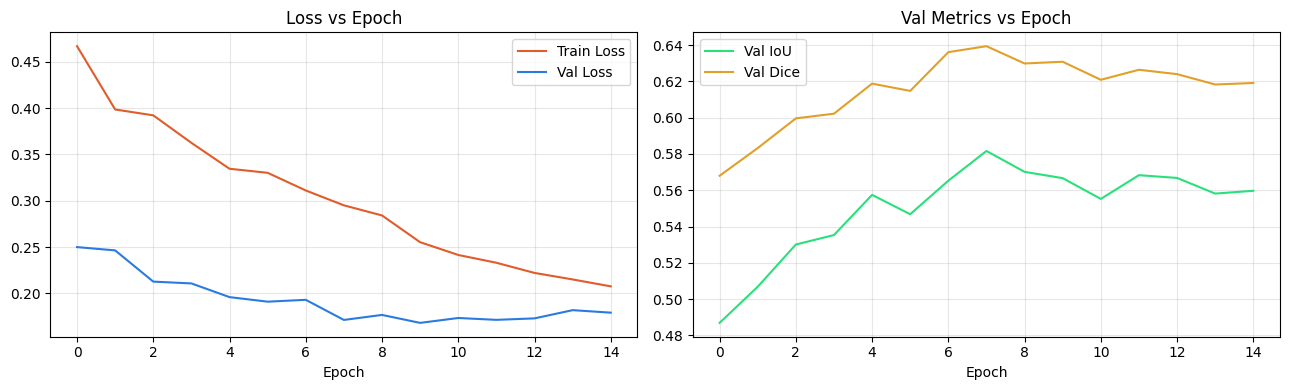

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['train_loss'], label='Train Loss', color='#E05C2A')
ax1.plot(history['val_loss'],   label='Val Loss',   color='#2A7BE0')
ax1.set_title('Loss vs Epoch'); ax1.set_xlabel('Epoch'); ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['val_iou'],  label='Val IoU',  color='#2AE07B')
ax2.plot(history['val_dice'], label='Val Dice', color='#E0A02A')
ax2.set_title('Val Metrics vs Epoch'); ax2.set_xlabel('Epoch'); ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [20]:
%%writefile /content/dashboard.py
import streamlit as st
import torch
import numpy as np
import json
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import sys
sys.path.insert(0, '/content')

# ── page config ──────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Wheat Rust Detection",
    page_icon="🌾",
    layout="wide"
)

st.title("🌾 Wheat Rust Disease Detection")
st.markdown("**CANet + EfficientNet-B4** | Binary Semantic Segmentation | NWRDF Dataset")
st.divider()

# ── load results ─────────────────────────────────────────────────────────────
@st.cache_data
def load_results():
    with open('/content/results.json') as f:
        return json.load(f)

results = load_results()
metrics = results['final_metrics']
history = results['history']
thresh  = results['best_threshold']

# ── TAB LAYOUT ───────────────────────────────────────────────────────────────
tab1, tab2, tab3 = st.tabs(["📊 Results", "📈 Training", "🔬 Predictions"])

# ══ TAB 1 — Results ══════════════════════════════════════════════════════════
with tab1:
    st.subheader("Final Evaluation Metrics")
    targets = {'IoU': 0.83, 'F1 / Dice': 0.90, 'Accuracy': 0.90, 'Specificity': 0.95}

    cols = st.columns(3)
    metric_list = list(metrics.items())
    for i, (k, v) in enumerate(metric_list):
        target = targets.get(k)
        delta  = f"{v - target:+.4f} vs target" if target else None
        color  = "normal" if not target else ("normal" if v >= target else "inverse")
        cols[i % 3].metric(label=k, value=f"{v:.4f}", delta=delta, delta_color=color)

    st.divider()
    st.subheader("Confusion Matrix")
    cm_img = Image.open('/content/confusion_matrix.png')
    st.image(cm_img, width=500)

# ══ TAB 2 — Training ═════════════════════════════════════════════════════════
with tab2:
    st.subheader("Training Curves")
    curves_img = Image.open('/content/training_curves.png')
    st.image(curves_img, use_column_width=True)

    st.divider()
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Loss**")
        for i, (tr, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
            st.text(f"Epoch {i+1:02d} | Train: {tr:.4f} | Val: {vl:.4f}")
    with col2:
        st.markdown("**Metrics**")
        for i, (iou, dice) in enumerate(zip(history['val_iou'], history['val_dice'])):
            st.text(f"Epoch {i+1:02d} | IoU: {iou:.4f} | Dice: {dice:.4f}")

# ══ TAB 3 — Predictions ══════════════════════════════════════════════════════
with tab3:
    st.subheader("Live Segmentation Predictions")
    st.markdown(f"Threshold: `{thresh}` | Only disease patches shown")

    # ── Custom Image Upload ───────────────────────────────────────────────────────
st.divider()
st.subheader("🖼️ Upload Your Own Image")
st.markdown("Upload a wheat leaf image to predict its rust segmentation mask.")

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png", "tif"],
    help="Upload a wheat leaf image (ideally 512×512 or larger)"
)

if uploaded_file is not None:
    # Read image
    file_bytes = np.frombuffer(uploaded_file.read(), np.uint8)
    img_raw    = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    img_raw    = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

    # Show original
    col_orig, col_info = st.columns([2, 1])
    with col_orig:
        st.image(img_raw, caption="Uploaded Image", use_column_width=True)
    with col_info:
        st.markdown("**Image Info**")
        st.write(f"Original size: `{img_raw.shape[1]} × {img_raw.shape[0]}`")
        st.write(f"Channels: `{img_raw.shape[2]}`")
        st.write(f"Threshold: `{thresh}`")

    # Preprocess
    img_resized = cv2.resize(img_raw, (512, 512))
    img_norm    = img_resized.astype(np.float32) / 255.0
    for c in range(3):
        img_norm[:,:,c] = (img_norm[:,:,c] - mean_t[c]) / std_t[c]
    inp = torch.tensor(img_norm).permute(2,0,1).unsqueeze(0).to(device_st)

    # Predict
    with st.spinner("Running segmentation..."):
        with torch.no_grad():
            pred_prob = torch.sigmoid(model_st(inp)).squeeze().cpu().numpy()
        pred_bin = (pred_prob > thresh).astype(np.uint8)

    # Overlay — green mask on original
    overlay      = img_resized.copy()
    rust_pixels  = pred_bin == 1
    overlay[rust_pixels] = (
        overlay[rust_pixels] * 0.4 + np.array([255, 60, 60]) * 0.6
    ).astype(np.uint8)

    # Disease coverage stats
    total_pixels   = pred_bin.size
    disease_pixels = pred_bin.sum()
    coverage_pct   = disease_pixels / total_pixels * 100

    # Display results
    st.markdown("#### Segmentation Results")
    c1, c2, c3, c4 = st.columns(4)
    c1.image(img_resized,
             caption="Resized Input (512×512)", use_column_width=True)
    c2.image((pred_prob * 255).astype(np.uint8),
             caption="Probability Heatmap", use_column_width=True)
    c3.image((pred_bin * 255).astype(np.uint8),
             caption="Binary Mask", use_column_width=True)
    c4.image(overlay,
             caption="Overlay (red = rust)", use_column_width=True)

    # Stats
    st.markdown("#### Disease Coverage")
    col_a, col_b, col_c = st.columns(3)
    col_a.metric("Rust Pixels",    f"{disease_pixels:,}")
    col_b.metric("Total Pixels",   f"{total_pixels:,}")
    col_c.metric("Coverage",       f"{coverage_pct:.2f}%",
                 delta="High risk" if coverage_pct > 10 else "Low risk",
                 delta_color="inverse" if coverage_pct > 10 else "normal")

    # Severity badge
    if coverage_pct == 0:
        st.success("✅ No rust detected — patch appears healthy.")
    elif coverage_pct < 5:
        st.warning(f"⚠️ Early-stage rust detected — {coverage_pct:.1f}% coverage.")
    elif coverage_pct < 20:
        st.error(f"🔴 Moderate rust infection — {coverage_pct:.1f}% coverage.")
    else:
        st.error(f"🚨 Severe rust infection — {coverage_pct:.1f}% coverage. Immediate intervention recommended.")

    # Download predicted mask
    from PIL import Image as PILImage
    import io
    mask_pil = PILImage.fromarray(pred_bin * 255)
    buf      = io.BytesIO()
    mask_pil.save(buf, format="PNG")
    st.download_button(
        label="⬇️ Download Predicted Mask",
        data=buf.getvalue(),
        file_name=f"rust_mask_{uploaded_file.name.split('.')[0]}.png",
        mime="image/png"
    )

    # ── load model ───────────────────────────────────────────────────────────
    @st.cache_resource
    def load_model():
        # inline model definition (minimal, same as training)
        import torch.nn as nn
        import torch.nn.functional as F
        from efficientnet_pytorch import EfficientNet

        class ConvBNReLU(nn.Module):
            def __init__(self, in_ch, out_ch, k=3, p=1, d=1):
                super().__init__()
                self.block = nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, k, padding=p, dilation=d, bias=False),
                    nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
            def forward(self, x): return self.block(x)

        class ContextFlow(nn.Module):
            def __init__(self, in_ch, out_ch, scale):
                super().__init__()
                self.scale  = scale
                self.encode = ConvBNReLU(in_ch, out_ch)
                self.decode = ConvBNReLU(out_ch, out_ch)
            def forward(self, x):
                h, w = x.shape[-2:]
                xd = F.avg_pool2d(x, self.scale) if self.scale > 1 else x
                f  = self.decode(self.encode(xd))
                return F.interpolate(f, (h,w), mode='bilinear', align_corners=False) if self.scale > 1 else f

        class AttentionFusion(nn.Module):
            def __init__(self, in_ch):
                super().__init__()
                self.att = nn.Sequential(
                    nn.Conv2d(in_ch, in_ch//4, 1), nn.ReLU(inplace=True),
                    nn.Conv2d(in_ch//4, in_ch, 1), nn.Sigmoid())
            def forward(self, x): return x * self.att(x)

        class CAM(nn.Module):
            def __init__(self, in_ch, out_ch=256):
                super().__init__()
                self.global_flow   = nn.Sequential(
                    ConvBNReLU(in_ch, out_ch, k=3, p=2, d=2),
                    ConvBNReLU(out_ch, out_ch, k=3, p=4, d=4),
                    ConvBNReLU(out_ch, out_ch, k=3, p=8, d=8))
                self.context_flows = nn.ModuleList([
                    ContextFlow(in_ch, out_ch, 2),
                    ContextFlow(in_ch, out_ch, 4),
                    ContextFlow(in_ch, out_ch, 8)])
                self.pre_fusion    = ConvBNReLU(out_ch*4, out_ch, k=1, p=0)
                self.re_fusion     = AttentionFusion(out_ch)
                self.out_conv      = ConvBNReLU(out_ch, out_ch)
            def forward(self, x):
                gf    = self.global_flow(x)
                cfs   = [cf(x) for cf in self.context_flows]
                fused = self.pre_fusion(torch.cat([gf]+cfs, dim=1))
                return self.out_conv(self.re_fusion(fused))

        class AsymmetricDecoder(nn.Module):
            def __init__(self, high_ch, low_ch, out_ch=128):
                super().__init__()
                self.low_reduce = ConvBNReLU(low_ch, 48, k=1, p=0)
                self.fuse = nn.Sequential(
                    ConvBNReLU(high_ch+48, out_ch), ConvBNReLU(out_ch, out_ch))
            def forward(self, high, low):
                high_up = F.interpolate(high, low.shape[-2:], mode='bilinear', align_corners=False)
                return self.fuse(torch.cat([high_up, self.low_reduce(low)], dim=1))


        # ── Custom Image Upload ───────────────────────────────────────────────────────
st.divider()
st.subheader("🖼️ Upload Your Own Image")
st.markdown("Upload a wheat leaf image to predict its rust segmentation mask.")

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png", "tif"],
    help="Upload a wheat leaf image (ideally 512×512 or larger)"
)

if uploaded_file is not None:
    # Read image
    file_bytes = np.frombuffer(uploaded_file.read(), np.uint8)
    img_raw    = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    img_raw    = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

    # Show original
    col_orig, col_info = st.columns([2, 1])
    with col_orig:
        st.image(img_raw, caption="Uploaded Image", use_column_width=True)
    with col_info:
        st.markdown("**Image Info**")
        st.write(f"Original size: `{img_raw.shape[1]} × {img_raw.shape[0]}`")
        st.write(f"Channels: `{img_raw.shape[2]}`")
        st.write(f"Threshold: `{thresh}`")

    # Preprocess
    img_resized = cv2.resize(img_raw, (512, 512))
    img_norm    = img_resized.astype(np.float32) / 255.0
    for c in range(3):
        img_norm[:,:,c] = (img_norm[:,:,c] - mean_t[c]) / std_t[c]
    inp = torch.tensor(img_norm).permute(2,0,1).unsqueeze(0).to(device_st)

    # Predict
    with st.spinner("Running segmentation..."):
        with torch.no_grad():
            pred_prob = torch.sigmoid(model_st(inp)).squeeze().cpu().numpy()
        pred_bin = (pred_prob > thresh).astype(np.uint8)

    # Overlay — green mask on original
    overlay      = img_resized.copy()
    rust_pixels  = pred_bin == 1
    overlay[rust_pixels] = (
        overlay[rust_pixels] * 0.4 + np.array([255, 60, 60]) * 0.6
    ).astype(np.uint8)

    # Disease coverage stats
    total_pixels   = pred_bin.size
    disease_pixels = pred_bin.sum()
    coverage_pct   = disease_pixels / total_pixels * 100

    # Display results
    st.markdown("#### Segmentation Results")
    c1, c2, c3, c4 = st.columns(4)
    c1.image(img_resized,
             caption="Resized Input (512×512)", use_column_width=True)
    c2.image((pred_prob * 255).astype(np.uint8),
             caption="Probability Heatmap", use_column_width=True)
    c3.image((pred_bin * 255).astype(np.uint8),
             caption="Binary Mask", use_column_width=True)
    c4.image(overlay,
             caption="Overlay (red = rust)", use_column_width=True)

    # Stats
    st.markdown("#### Disease Coverage")
    col_a, col_b, col_c = st.columns(3)
    col_a.metric("Rust Pixels",    f"{disease_pixels:,}")
    col_b.metric("Total Pixels",   f"{total_pixels:,}")
    col_c.metric("Coverage",       f"{coverage_pct:.2f}%",
                 delta="High risk" if coverage_pct > 10 else "Low risk",
                 delta_color="inverse" if coverage_pct > 10 else "normal")

    # Severity badge
    if coverage_pct == 0:
        st.success("✅ No rust detected — patch appears healthy.")
    elif coverage_pct < 5:
        st.warning(f"⚠️ Early-stage rust detected — {coverage_pct:.1f}% coverage.")
    elif coverage_pct < 20:
        st.error(f"🔴 Moderate rust infection — {coverage_pct:.1f}% coverage.")
    else:
        st.error(f"🚨 Severe rust infection — {coverage_pct:.1f}% coverage. Immediate intervention recommended.")

    # Download predicted mask
    from PIL import Image as PILImage
    import io
    mask_pil = PILImage.fromarray(pred_bin * 255)
    buf      = io.BytesIO()
    mask_pil.save(buf, format="PNG")
    st.download_button(
        label="⬇️ Download Predicted Mask",
        data=buf.getvalue(),
        file_name=f"rust_mask_{uploaded_file.name.split('.')[0]}.png",
        mime="image/png"
    )
    class CANet(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = EfficientNet.from_pretrained('efficientnet-b4')
                self.reduce  = ConvBNReLU(1792, 512, k=1, p=0)
                self.cam     = CAM(512, 256)
                self.decoder = AsymmetricDecoder(256, 32, 128)
                self.dropout = nn.Dropout2d(0.3)
                self.head    = nn.Sequential(
                    nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(inplace=True),
                    nn.Conv2d(64, 1, 1))
            def forward(self, x):
                enc       = self.encoder.extract_features(x)
                low       = self.encoder.extract_endpoints(x)['reduction_2']
                x_cam     = self.cam(self.reduce(enc))
                x_dec     = self.dropout(self.decoder(x_cam, low))
                out       = self.head(x_dec)
                return F.interpolate(out, scale_factor=4, mode='bilinear', align_corners=False)

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        m = CANet().to(device)
        ckpt = torch.load('/content/best_model.pth', map_location=device)
        m.load_state_dict(ckpt['model'])
        m.eval()
        return m, device

    model_st, device_st = load_model()

    # ── find disease patches ─────────────────────────────────────────────────
    @st.cache_data
    def get_disease_files(img_dir, mask_dir):
        files = sorted(os.listdir(img_dir))
        out   = []
        for f in files:
            mask = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
            if mask is not None and (mask > 127).sum() > 0:
                out.append(f)
        return out

    VAL_IMG_DIR  = os.environ.get('VAL_IMG_DIR',  '')
    VAL_MASK_DIR = os.environ.get('VAL_MASK_DIR', '')

    if not VAL_IMG_DIR:
        st.warning("Set VAL_IMG_DIR and VAL_MASK_DIR env vars before launching dashboard.")
        st.stop()

    disease_files = get_disease_files(VAL_IMG_DIR, VAL_MASK_DIR)
    st.info(f"{len(disease_files)} disease patches available")

    n_samples = st.slider("Number of samples to display", 2, 8, 4)
    if st.button("🎲 Sample random patches"):
        st.session_state['samples'] = random.sample(disease_files, min(n_samples, len(disease_files)))

    if 'samples' not in st.session_state:
        st.session_state['samples'] = random.sample(disease_files, min(n_samples, len(disease_files)))

    mean_t = [0.485, 0.456, 0.406]
    std_t  = [0.229, 0.224, 0.225]

    for fname in st.session_state['samples']:
        img_raw  = cv2.cvtColor(cv2.imread(os.path.join(VAL_IMG_DIR, fname)), cv2.COLOR_BGR2RGB)
        mask_raw = cv2.imread(os.path.join(VAL_MASK_DIR, fname), cv2.IMREAD_GRAYSCALE)
        img_raw  = cv2.resize(img_raw,  (512, 512))
        mask_raw = cv2.resize(mask_raw, (512, 512))

        # normalise + tensor
        img_n = img_raw.astype(np.float32) / 255.0
        for c in range(3): img_n[:,:,c] = (img_n[:,:,c] - mean_t[c]) / std_t[c]
        inp   = torch.tensor(img_n).permute(2,0,1).unsqueeze(0).to(device_st)

        with torch.no_grad():
            pred_prob = torch.sigmoid(model_st(inp)).squeeze().cpu().numpy()
        pred_bin = (pred_prob > thresh).astype(np.uint8)

        c1, c2, c3, c4 = st.columns(4)
        c1.image(img_raw,                        caption="Original",         use_column_width=True)
        c2.image(mask_raw,                       caption="Ground Truth",     use_column_width=True, clamp=True)
        c3.image((pred_prob * 255).astype(np.uint8), caption="Probability Map", use_column_width=True)
        c4.image((pred_bin  * 255).astype(np.uint8), caption="Predicted Mask",  use_column_width=True)
        st.caption(f"**{fname}**")
        st.divider()

Writing /content/dashboard.py


In [22]:
pip install pyngrok -q

In [23]:
import os
import subprocess
import threading
from pyngrok import ngrok
import time

# Set dataset paths for dashboard
os.environ['VAL_IMG_DIR']  = cfg.val_img_dir
os.environ['VAL_MASK_DIR'] = cfg.val_mask_dir

# Kill any existing streamlit
os.system("pkill -f streamlit")
time.sleep(1)

# Launch
def run():
    os.system("streamlit run /content/dashboard.py --server.port 8501 --server.headless true")

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(4)

# ngrok tunnel
ngrok.kill()
tunnel = ngrok.connect(8501)
print(f"\n🌾 Dashboard live at: {tunnel.public_url}\n")

ERROR:pyngrok.process.ngrok:t=2026-04-30T04:58:11+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-30T04:58:11+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-30T04:58:11+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.